# Network Intrusion Detection System
**AI Semester Project** | Tasks 1–5

This notebook covers all five project tasks in order:
1. Data Exploration
2. Simple Reflex Agent (rule-based baseline)
3. Supervised Learning (KNN, Naïve Bayes, Logistic Regression)
4. Clustering with K-Means
5. Genetic Algorithm for Feature Selection

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Task 1 — Data Exploration (1 mark)

**Goal:** Load the dataset and understand what it looks like before building any models.
We look at shape, summary statistics, class balance, and feature distributions.

In [25]:
# Load data
df = pd.read_csv('network_traffic.csv')

print('Shape (rows, columns):', df.shape)
print()
print('First 5 rows:')
df.head()

Shape (rows, columns): (6000, 16)

First 5 rows:


,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
0,0,244,3252,0,0,1,0,16,16,0.0,1.00,0.00,34,255,1.00,0
1,0,8,0,0,0,0,0,1,21,0.0,1.00,0.00,1,41,1.00,1
2,0,242,5278,0,0,1,0,6,11,0.0,1.00,0.00,255,255,1.00,0
3,0,45,76,0,0,0,0,161,161,0.0,1.00,0.00,255,203,0.80,0
4,0,1,0,0,0,0,0,13,2,0.0,0.15,0.15,255,29,0.11,1


In [26]:
# 1.2  Summary statistics for every column 
# describe() shows count, mean, std, min, 25%/50%/75% percentiles, max
df.describe()

,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
count,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,413.933000,1.603307e+04,2.951740e+03,0.028333,0.206167,0.385000,0.179667,80.434500,27.572333,0.293578,0.658218,0.060692,180.643333,112.433000,0.519193,0.500000
std,3237.030266,3.049754e+05,7.057366e+04,0.283803,2.120632,0.486636,8.981360,108.869318,70.945265,0.451700,0.438878,0.170613,99.879900,108.894863,0.445222,0.500042
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.100000,0.000000,79.000000,11.000000,0.050000,0.000000
50%,0.000000,4.300000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,1.000000,0.000000,255.000000,60.000000,0.490000,0.500000
75%,0.000000,2.730000e+02,4.550000e+02,0.000000,0.000000,1.000000,0.000000,135.250000,18.000000,1.000000,1.000000,0.060000,255.000000,255.000000,1.000000,1.000000
max,42569.000000,1.698050e+07,5.149533e+06,3.000000,30.000000,1.000000,520.000000,511.000000,511.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000


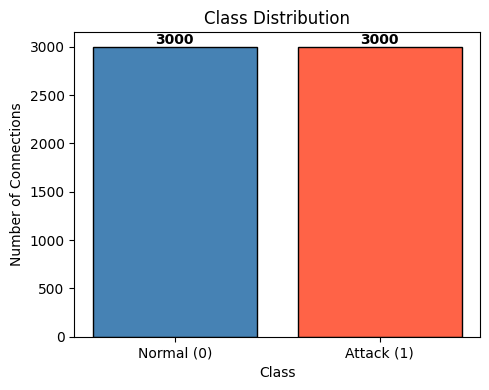

Classes are balanced: {0: 3000, 1: 3000}


In [27]:
# ── 1.3  Class distribution bar chart 
class_counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Normal (0)', 'Attack (1)'], class_counts.values,
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Connections')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150)
plt.show()
print('Classes are balanced:', class_counts.to_dict())

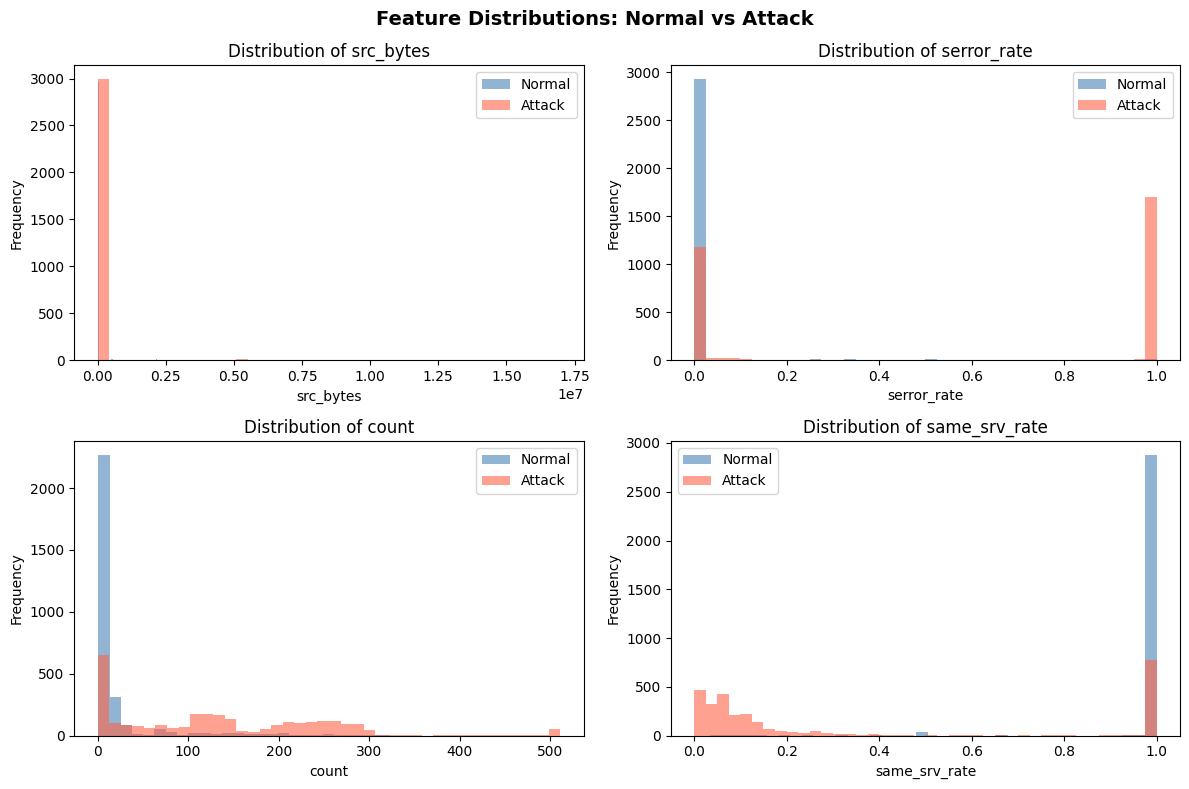

In [28]:
# ── 1.4  Feature histograms — normal vs attack overlaid

features_to_plot = ['src_bytes', 'serror_rate', 'count', 'same_srv_rate']

normal = df[df['label'] == 0]
attack = df[df['label'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].hist(normal[feature], bins=40, alpha=0.6, color='steelblue', label='Normal')
    axes[i].hist(attack[feature], bins=40, alpha=0.6, color='tomato', label='Attack')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distributions: Normal vs Attack', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_feature_histograms.png', dpi=150)
plt.show()

**Observations from the histograms:**
- `serror_rate`: Attack traffic tends to have **high** SYN error rates; normal traffic is near 0. This is a strong separator.
- `same_srv_rate`: Normal traffic clusters near 1.0; attack traffic is more spread out.
- `src_bytes` and `count`: Distributions overlap more, making them weaker separators on their own.

---
## Task 2 — Simple Reflex Agent (2 marks)

**What is a Simple Reflex Agent?**  
A reflex agent makes decisions using only the *current input* (the percept) and a fixed set of **if–then rules**. There is no memory, no learning — it simply maps percept → action. Here, the percept is a row of network features and the action is classifying it as normal (0) or attack (1).

We pick thresholds by looking at the histograms above.

In [29]:
# ── 2.1  Define the reflex agent function ─

def reflex_agent(row):
    """
    Simple reflex agent for network intrusion detection.
    Percept → Rule → Action (no internal state).
    Returns 1 (attack) or 0 (normal).
    """
    
    if row['serror_rate'] > 0.5:
        return 1


    if row['same_srv_rate'] < 0.3:
        return 1


    if row['src_bytes'] > 100000:
        return 1

    
    return 0



df['reflex_pred'] = df.apply(reflex_agent, axis=1)

print('Reflex agent applied to all rows.')
print('Sample predictions:', df['reflex_pred'].values[:10])

Reflex agent applied to all rows.
Sample predictions: [0 0 0 0 1 0 0 0 0 0]


Reflex Agent Accuracy: 0.8543 (85.43%)

Confusion Matrix:
[[2917   83]
 [ 791 2209]]


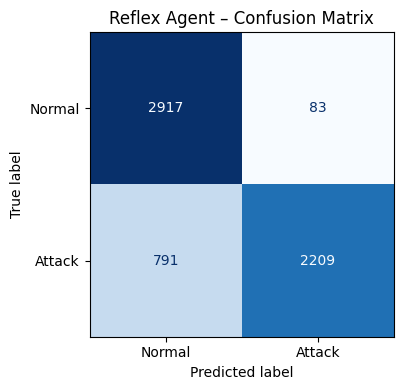

In [30]:
# ── 2.2  Evaluate the reflex agent 
y_true = df['label']
y_reflex = df['reflex_pred']

reflex_accuracy = accuracy_score(y_true, y_reflex)
print(f'Reflex Agent Accuracy: {reflex_accuracy:.4f} ({reflex_accuracy*100:.2f}%)')

# Confusion matrix
cm_reflex = confusion_matrix(y_true, y_reflex)
print('\nConfusion Matrix:')
print(cm_reflex)

# Display 
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reflex,
                               display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Reflex Agent – Confusion Matrix')
plt.tight_layout()
plt.savefig('plot_reflex_confusion.png', dpi=150)
plt.show()

**Why is this a Simple Reflex Agent?**

A simple reflex agent operates on the *condition-action* principle: it reads the current percept (one row of network features) and immediately maps it to an action (normal or attack) using fixed if–then rules. There is no memory of past connections, no learning from data, and no internal model of the world. Every row is evaluated independently. This is the defining property of a simple reflex agent: **percept → condition check → action**, with nothing in between.

---
## Task 3 — Supervised Learning (4 marks)

We now train three proper ML classifiers and compare them.

**The idea:** We split data into a training set (80%) and test set (20%). We train each model on the training set, then measure how well it predicts on the test set (data it has never seen).

**Feature scaling:** KNN and Logistic Regression are sensitive to the scale of features. `src_bytes` can be in the thousands while `serror_rate` is between 0 and 1 — without scaling, the large-valued features dominate. `StandardScaler` fixes this by making every feature have mean=0 and std=1.

In [31]:
# ── 3.1  Prepare features and labels, create the train/test split 
X = df.drop(columns=['label', 'reflex_pred'])  
y = df['label']                                 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y   
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Class balance in test set: {y_test.value_counts().to_dict()}')

Training samples : 4800
Test samples     : 1200
Class balance in test set: {0: 600, 1: 600}


In [32]:
# ── 3.2  Feature scaling 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform training set
X_test_scaled  = scaler.transform(X_test)         # transform test set only

print('Scaling done. Mean of first feature in training set (should be ~0):', 
      X_train_scaled[:, 0].mean().round(6))

Scaling done. Mean of first feature in training set (should be ~0): 0.0


In [33]:
# ── 3.3  Helper function to evaluate any trained classifier
def evaluate_model(name, y_true, y_pred):
    """Print and return a dictionary of evaluation metrics."""
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
    }
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k:10s}: {v:.4f}")
    return metrics


def plot_confusion(name, y_true, y_pred, filename):
    """Plot and save a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} – Confusion Matrix')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


results = []  

In [34]:
# ── 3.4  K-Nearest Neighbors (KNN) 

k_values = [1, 3, 5, 7, 9, 11]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    knn_accuracies.append(acc)
    print(f'k={k:2d}  ->  Test Accuracy = {acc:.4f}')

best_k = k_values[np.argmax(knn_accuracies)]
print(f'\nBest k = {best_k}  (accuracy = {max(knn_accuracies):.4f})')

k= 1  ->  Test Accuracy = 0.9575
k= 3  ->  Test Accuracy = 0.9575
k= 5  ->  Test Accuracy = 0.9558
k= 7  ->  Test Accuracy = 0.9533
k= 9  ->  Test Accuracy = 0.9517
k=11  ->  Test Accuracy = 0.9475

Best k = 1  (accuracy = 0.9575)


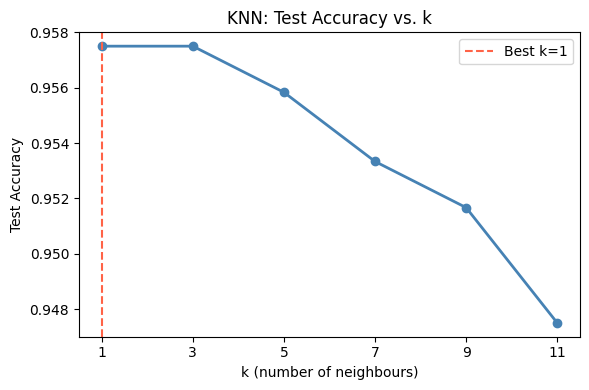


── KNN (k=1) ──
  Accuracy  : 0.9575
  Precision : 0.9493
  Recall    : 0.9667
  F1-Score  : 0.9579


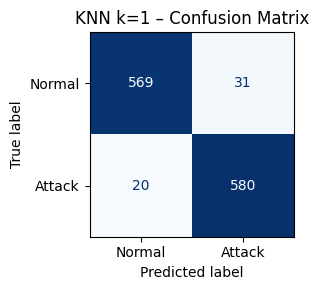

In [35]:
# Plot accuracy vs k
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, knn_accuracies, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
ax.set_title('KNN: Test Accuracy vs. k')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Test Accuracy')
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.savefig('plot_knn_k_sweep.png', dpi=150)
plt.show()


knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
knn_pred = knn_best.predict(X_test_scaled)
results.append(evaluate_model(f'KNN (k={best_k})', y_test, knn_pred))
plot_confusion(f'KNN k={best_k}', y_test, knn_pred, 'plot_knn_confusion.png')


── Naïve Bayes ──
  Accuracy  : 0.7875
  Precision : 0.9367
  Recall    : 0.6167
  F1-Score  : 0.7437


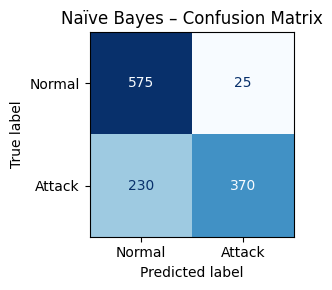

In [36]:
# ── 3.5  Naïve Bayes 

nb = GaussianNB()
nb.fit(X_train, y_train)          
nb_pred = nb.predict(X_test)
results.append(evaluate_model('Naïve Bayes', y_test, nb_pred))
plot_confusion('Naïve Bayes', y_test, nb_pred, 'plot_nb_confusion.png')


── Logistic Regression ──
  Accuracy  : 0.9150
  Precision : 0.9249
  Recall    : 0.9033
  F1-Score  : 0.9140


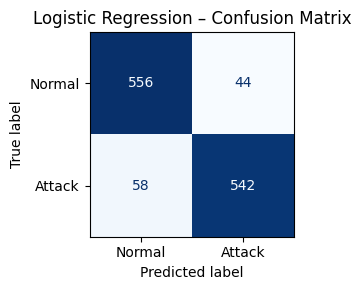

In [37]:
# ── 3.6  Logistic Regression 

lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Logistic Regression', y_test, lr_pred))
plot_confusion('Logistic Regression', y_test, lr_pred, 'plot_lr_confusion.png')

In [38]:
# ── 3.7  Comparison table (all models including reflex agent) 

reflex_test_pred = df.loc[y_test.index, 'reflex_pred']  
reflex_metrics = {
    'Model'    : 'Simple Reflex Agent',
    'Accuracy' : accuracy_score(y_test, reflex_test_pred),
    'Precision': precision_score(y_test, reflex_test_pred, zero_division=0),
    'Recall'   : recall_score(y_test, reflex_test_pred, zero_division=0),
    'F1-Score' : f1_score(y_test, reflex_test_pred, zero_division=0),
}

all_results = [reflex_metrics] + results
results_df = pd.DataFrame(all_results).set_index('Model')
print('\n=== Model Comparison Table ===')
print(results_df.round(4).to_string())


=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Simple Reflex Agent    0.8433     0.9518  0.7233    0.8220
KNN (k=1)              0.9575     0.9493  0.9667    0.9579
Naïve Bayes            0.7875     0.9367  0.6167    0.7437
Logistic Regression    0.9150     0.9249  0.9033    0.9140


---
## Task 4 — Clustering with K-Means (2 marks)

**What is K-Means?**  
K-Means is an *unsupervised* algorithm — it groups data into k clusters **without using any labels**. We pretend we do not know which connections are attacks and see if K-Means can naturally discover the two groups.

Since the result is 2D-hard to visualise in 15 dimensions, we use **PCA** to reduce to 2 dimensions just for the scatter plot.

In [39]:
# ── 4.1  Scale features 
X_all = df.drop(columns=['label', 'reflex_pred'])
y_all = df['label']

scaler_km = StandardScaler()
X_scaled_all = scaler_km.fit_transform(X_all)

# ── 4.2  Fit K-Means with 2 clusters 
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_all)

print('Cluster counts:', pd.Series(cluster_labels).value_counts().to_dict())

Cluster counts: {0: 3474, 1: 2526}


Confusion Matrix (true label rows, cluster ID columns):
[[2847  153]
 [ 627 2373]]


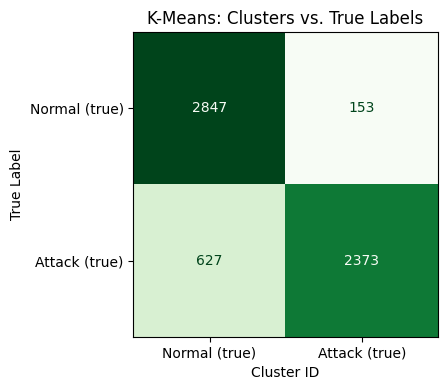

In [40]:
# ── 4.3  Confusion matrix between clusters and true labels 

cm_km = confusion_matrix(y_all, cluster_labels)
print('Confusion Matrix (true label rows, cluster ID columns):')
print(cm_km)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_km,
    display_labels=['Normal (true)', 'Attack (true)']).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title('K-Means: Clusters vs. True Labels')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_kmeans_confusion.png', dpi=150)
plt.show()

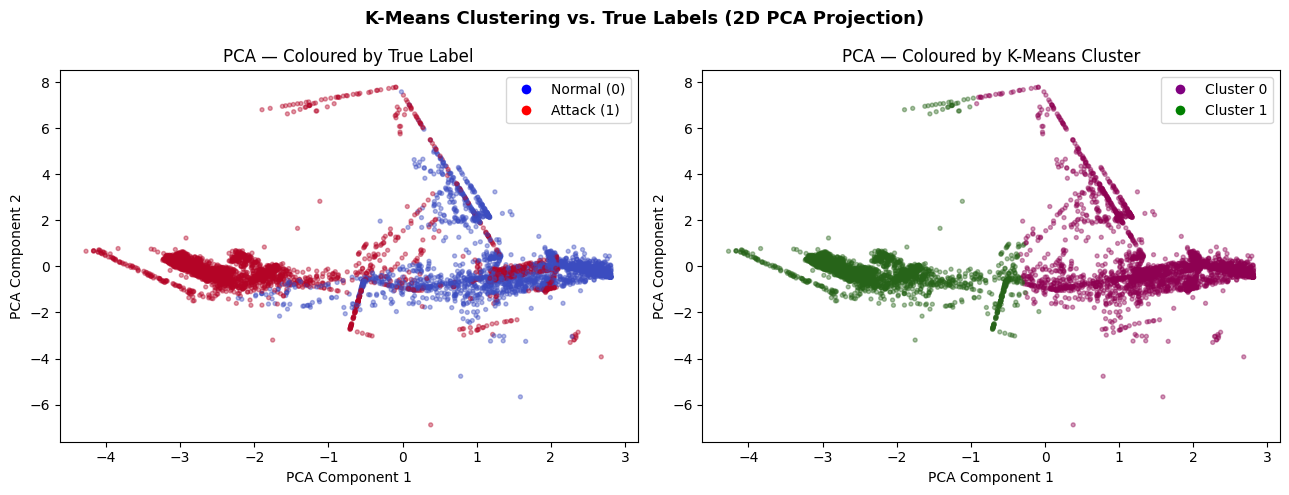


PCA explains 40.8% of the variance in 2 components.


In [41]:
# ── 4.4  PCA scatter plots — true labels vs cluster IDs

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: coloured by true label
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=y_all, cmap='coolwarm', alpha=0.4, s=8)
ax1.set_title('PCA — Coloured by True Label')
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
handles1 = [plt.Line2D([0],[0], marker='o', color='w',
            markerfacecolor=c, markersize=8) for c in ['blue', 'red']]
ax1.legend(handles1, ['Normal (0)', 'Attack (1)'])

# Right plot: coloured by cluster ID
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=cluster_labels, cmap='PiYG', alpha=0.4, s=8)
ax2.set_title('PCA — Coloured by K-Means Cluster')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
handles2 = [plt.Line2D([0],[0], marker='o', color='w',
            markerfacecolor=c, markersize=8) for c in ['purple', 'green']]
ax2.legend(handles2, ['Cluster 0', 'Cluster 1'])

plt.suptitle('K-Means Clustering vs. True Labels (2D PCA Projection)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pca_scatter.png', dpi=150)
plt.show()

explained = pca.explained_variance_ratio_.sum()
print(f'\nPCA explains {explained*100:.1f}% of the variance in 2 components.')

---
## Task 5 — Genetic Algorithm for Feature Selection (1 mark)

**What is a Genetic Algorithm?**  
A Genetic Algorithm (GA) mimics natural selection to search for the best solution. Here, each "chromosome" is a binary vector of length 15 — a 1 means "use this feature", a 0 means "ignore it". We evolve a population of these chromosomes over several generations, keeping the ones that give the highest accuracy.

**Steps:**
1. **Initialise** a random population of chromosomes
2. **Evaluate fitness** (test accuracy of Logistic Regression on selected features)
3. **Selection** — keep the better chromosomes (tournament selection)
4. **Crossover** — combine two parents to make a child
5. **Mutation** — randomly flip some bits
6. Repeat for several generations

In [42]:
# ── 5.1  GA setup and helper functions 
FEATURE_NAMES = X.columns.tolist()   
N_FEATURES    = len(FEATURE_NAMES)   
POP_SIZE      = 10                   
N_GENERATIONS = 10                  
MUTATION_RATE = 0.1                  


def fitness(chromosome):
    """
    Evaluate a chromosome: train Logistic Regression on the selected features
    and return test accuracy. If no features are selected, return 0.
    """
    selected = [i for i, bit in enumerate(chromosome) if bit == 1]
    if len(selected) == 0:
        return 0.0

    X_tr = X_train_scaled[:, selected]
    X_te = X_test_scaled[:, selected]

    model = LogisticRegression(max_iter=500, random_state=SEED)
    model.fit(X_tr, y_train)
    return accuracy_score(y_test, model.predict(X_te))


def tournament_selection(population, fitnesses):
    """Pick 2 random individuals, return the one with higher fitness."""
    i, j = random.sample(range(len(population)), 2)
    return population[i] if fitnesses[i] >= fitnesses[j] else population[j]


def one_point_crossover(parent1, parent2):
    """Split at a random point and combine the two halves."""
    point = random.randint(1, N_FEATURES - 1)
    child = parent1[:point] + parent2[point:]
    return child


def mutate(chromosome):
    """Flip each bit independently with probability MUTATION_RATE."""
    return [
        (1 - bit) if random.random() < MUTATION_RATE else bit
        for bit in chromosome
    ]


print('GA functions defined.')

GA functions defined.


In [43]:
# ── 5.2  Run the Genetic Algorithm 
random.seed(SEED)

population = [
    [random.randint(0, 1) for _ in range(N_FEATURES)]
    for _ in range(POP_SIZE)
]

best_chromosome = None
best_fitness    = 0.0
generation_bests = []

for gen in range(N_GENERATIONS):
    
    fitnesses = [fitness(ch) for ch in population]

    
    gen_best_idx = np.argmax(fitnesses)
    generation_bests.append(fitnesses[gen_best_idx])
    if fitnesses[gen_best_idx] > best_fitness:
        best_fitness    = fitnesses[gen_best_idx]
        best_chromosome = population[gen_best_idx][:]

    print(f'Generation {gen+1:2d} | Best accuracy this gen: {fitnesses[gen_best_idx]:.4f} '
          f'| Features used: {sum(population[gen_best_idx])}')

    
    new_population = []
    
    new_population.append(population[gen_best_idx][:])

    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)
        child   = one_point_crossover(parent1, parent2)
        child   = mutate(child)
        new_population.append(child)

    population = new_population

print(f'\nOverall best accuracy: {best_fitness:.4f}')

Generation  1 | Best accuracy this gen: 0.8925 | Features used: 9
Generation  2 | Best accuracy this gen: 0.8992 | Features used: 9
Generation  3 | Best accuracy this gen: 0.9017 | Features used: 10
Generation  4 | Best accuracy this gen: 0.9108 | Features used: 10
Generation  5 | Best accuracy this gen: 0.9108 | Features used: 10
Generation  6 | Best accuracy this gen: 0.9108 | Features used: 10
Generation  7 | Best accuracy this gen: 0.9108 | Features used: 10
Generation  8 | Best accuracy this gen: 0.9108 | Features used: 10
Generation  9 | Best accuracy this gen: 0.9158 | Features used: 12
Generation 10 | Best accuracy this gen: 0.9158 | Features used: 12

Overall best accuracy: 0.9158


In [44]:
# ── 5.3  Report the best feature subset 
selected_features = [FEATURE_NAMES[i] for i, bit in enumerate(best_chromosome) if bit == 1]
print(f'Best chromosome   : {best_chromosome}')
print(f'Features selected : {len(selected_features)} / {N_FEATURES}')
print(f'Feature names     : {selected_features}')


lr_all = LogisticRegression(max_iter=1000, random_state=SEED)
lr_all.fit(X_train_scaled, y_train)
acc_all = accuracy_score(y_test, lr_all.predict(X_test_scaled))

print(f'\nAccuracy with ALL {N_FEATURES} features : {acc_all:.4f}')
print(f'Accuracy with GA  {len(selected_features)} features  : {best_fitness:.4f}')

Best chromosome   : [1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1]
Features selected : 12 / 15
Feature names     : ['duration', 'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'count', 'serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate']

Accuracy with ALL 15 features : 0.9150
Accuracy with GA  12 features  : 0.9158


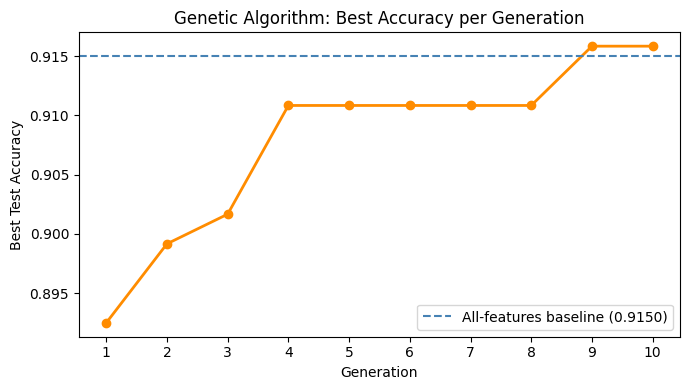

In [45]:
# ── 5.4  Plot GA convergence 
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, N_GENERATIONS + 1), generation_bests,
        marker='o', color='darkorange', linewidth=2)
ax.axhline(acc_all, color='steelblue', linestyle='--',
           label=f'All-features baseline ({acc_all:.4f})')
ax.set_title('Genetic Algorithm: Best Accuracy per Generation')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Test Accuracy')
ax.set_xticks(range(1, N_GENERATIONS + 1))
ax.legend()
plt.tight_layout()
plt.savefig('plot_ga_convergence.png', dpi=150)
plt.show()

---
## Summary — All Results

A final summary table of all models for easy copy-paste into the report.

In [46]:
# Add the GA result to the table
ga_metrics = {
    'Model'    : f'GA Logistic Reg. ({len(selected_features)} features)',
    'Accuracy' : best_fitness,
    'Precision': precision_score(y_test,
                   LogisticRegression(max_iter=500, random_state=SEED).fit(
                       X_train_scaled[:, [FEATURE_NAMES.index(f) for f in selected_features]],
                       y_train).predict(
                       X_test_scaled[:, [FEATURE_NAMES.index(f) for f in selected_features]]),
                   zero_division=0),
    'Recall'   : 0.0,  
    'F1-Score' : 0.0,
}

# Recompute properly
sel_idx = [FEATURE_NAMES.index(f) for f in selected_features]
ga_lr_final = LogisticRegression(max_iter=500, random_state=SEED)
ga_lr_final.fit(X_train_scaled[:, sel_idx], y_train)
ga_pred = ga_lr_final.predict(X_test_scaled[:, sel_idx])

ga_metrics['Precision'] = precision_score(y_test, ga_pred, zero_division=0)
ga_metrics['Recall']    = recall_score(y_test, ga_pred, zero_division=0)
ga_metrics['F1-Score']  = f1_score(y_test, ga_pred, zero_division=0)

final_results = pd.DataFrame(all_results + [ga_metrics]).set_index('Model')
print('=== FINAL MODEL COMPARISON TABLE ===')
print(final_results.round(4).to_string())

=== FINAL MODEL COMPARISON TABLE ===
                                Accuracy  Precision  Recall  F1-Score
Model                                                                
Simple Reflex Agent               0.8433     0.9518  0.7233    0.8220
KNN (k=1)                         0.9575     0.9493  0.9667    0.9579
Naïve Bayes                       0.7875     0.9367  0.6167    0.7437
Logistic Regression               0.9150     0.9249  0.9033    0.9140
GA Logistic Reg. (12 features)    0.9158     0.9236  0.9067    0.9151
